**1. DATA LOADING AND INITIAL INSPECTION**

In [1]:
# Environment setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from google.colab import drive
from scipy.stats import chi2_contingency

warnings.filterwarnings('ignore')

print('Libraries imported successfully')

Libraries imported successfully


In [2]:
# Default size of figures
plt.rcParams["figure.figsize"] = (8,5)

# Letter size
plt.rcParams["font.size"] = 11

In [3]:
# Google drive connection

drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/Credit_Risk_Project/data/raw/Loan_default.csv"

Mounted at /content/drive


In [4]:
# Dataset loading

try:
  df = pd.read_csv(file_path, encoding='latin-1')
  print('Dataset loaded succesfully')
except FileNotFoundError:
  print(f"Error: The file was not found at '{file_path}'")
except Exception as e:
  print(f"Error loading the dataset: {e}")

Dataset loaded succesfully


**Risk analytics utility library**

**NUMERIC VARIABLES**

**DESCRIPTIVE FUNCTIONS**

In [5]:
def calculate_descriptive_stats(
    df: pd.DataFrame,
    feature_col: str,
    target_col: str = "Default"
) -> pd.DataFrame:
    """
    Calculate descriptive statistics grouped by the target variable.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.

    feature_col : str
        Numerical feature to summarize.

    target_col : str, default="Default"
        Target variable.

    Returns
    -------
    pandas.DataFrame
        Descriptive statistics by target class.
    """

    if feature_col not in df.columns:
        raise ValueError(f"Column '{feature_col}' does not exist.")

    if target_col not in df.columns:
        raise ValueError(f"Column '{target_col}' does not exist.")

    stats = (
        df
        .groupby(target_col, observed=False)[feature_col]
        .describe()
        .round(2)
    )

    return stats

**STATISTICAL FUNCTIONS**

In [6]:
def calculate_default_rate(
    df: pd.DataFrame,
    category_col: str,
    target_col: str = "Default"
) -> pd.DataFrame:
    """
    Calculate the default rate for each category.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.

    category_col : str
        Column used to group observations.

    target_col : str, default="Default"
        Binary target variable.

    Returns
    -------
    pandas.DataFrame
        DataFrame containing the default rate (%) for each category.
    """

    # Validation
    if category_col not in df.columns:
        raise ValueError(
            f"Column '{category_col}' does not exist."
        )

    if target_col not in df.columns:
        raise ValueError(
            f"Column '{target_col}' does not exist."
        )

    risk = (
        df
        .groupby(category_col, observed=False)[target_col]
        .mean()
        .mul(100)
        .round(2)
        .reset_index(name="DefaultRate")
    )

    return risk

**VISUALIZATION FUNCTIONS**

In [7]:
def plot_boxplot(
    df: pd.DataFrame,
    feature_col: str,
    target_col: str = "Default"
) -> None:
    """
    Plot a boxplot grouped by the target variable.
    """

    if feature_col not in df.columns:
        raise ValueError(f"Column '{feature_col}' does not exist.")

    plt.figure(figsize=(6,5))

    df.boxplot(
        column=feature_col,
        by=target_col
    )

    plt.title(f"{feature_col} by {target_col}")
    plt.suptitle("")
    plt.xlabel(target_col)
    plt.ylabel(feature_col)

    plt.show()

In [8]:
def plot_histogram(
    df: pd.DataFrame,
    feature_col: str,
    target_col: str = "Default",
    bins: int = 30,
    alpha: float = 0.6,
    figsize: tuple = (8,5)
) -> None:
    """
    Plot overlapping histograms by target class.
    """

    if feature_col not in df.columns:
        raise ValueError(f"Column '{feature_col}' does not exist.")

    if target_col not in df.columns:
        raise ValueError(f"Column '{target_col}' does not exist.")

    plt.figure(figsize=figsize)

    for value in sorted(df[target_col].unique()):

        plt.hist(
            df[df[target_col] == value][feature_col],
            bins=bins,
            alpha=alpha,
            label=f"{target_col} = {value}"
        )

    plt.title(feature_col)
    plt.xlabel(feature_col)
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [9]:
def plot_default_rate(
    risk_df: pd.DataFrame,
    category_col: str,
    value_col: str = "DefaultRate",
    figsize: tuple = (8, 5)
) -> None:
    """
    Plot the default rate for each category.

    Parameters
    ----------
    risk_df : pandas.DataFrame
        DataFrame containing the category and default rate.

    category_col : str
        Column containing the categories.

    value_col : str, default="DefaultRate"
        Column containing the default rate.

    figsize : tuple, default=(8,5)
        Figure size.

    Returns
    -------
    None
    """

    # Validation
    if category_col not in risk_df.columns:
        raise ValueError(
            f"Column '{category_col}' does not exist."
        )

    if value_col not in risk_df.columns:
        raise ValueError(
            f"Column '{value_col}' does not exist."
        )

    plt.figure(figsize=figsize)

    plt.bar(
        risk_df[category_col].astype(str),
        risk_df[value_col]
    )

    plt.title(f"Default Rate by {category_col}")
    plt.xlabel(category_col)
    plt.ylabel("Default Rate (%)")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

**FEATURE ENGINEERING FUNCTIONS**

In [10]:
def create_quantile_bands(
    df: pd.DataFrame,
    feature_col: str,
    q: int = 5,
    labels: list | None = None,
    precision: int = 2
) -> pd.DataFrame:
    """
    Create quantile-based bands for a numerical feature.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.

    feature_col : str
        Numerical feature to discretize.

    q : int, default=5
        Number of quantiles.

    labels : list, optional
        Labels for the quantile bands.

    precision : int, default=2
        Decimal precision for interval labels.

    Returns
    -------
    pandas.DataFrame
        Copy of the dataframe with a new quantile band column.
    """

    # Work on a copy to avoid modifying the original DataFrame
    df = df.copy()

    # Validation
    if feature_col not in df.columns:
        raise ValueError(
            f"Column '{feature_col}' does not exist."
        )

    if labels is not None and len(labels) != q:
        raise ValueError(
            "Number of labels must equal the number of quantiles."
        )

    band_name = f"{feature_col}_Band"

    df[band_name] = pd.qcut(
        df[feature_col],
        q=q,
        labels=labels,
        precision=precision,
        duplicates="drop"
    )

    return df

**CATEGORICAL VARIABLES**

In [11]:
def calculate_category_distribution(
    df: pd.DataFrame,
    feature_col: str
) -> pd.DataFrame:
    """
    Calculate frequency and percentage distribution
    of a categorical variable.
    """

    if feature_col not in df.columns:
        raise ValueError(
            f"Column '{feature_col}' does not exist."
        )

    distribution = (
        df[feature_col]
        .value_counts(dropna=False)
        .rename_axis(feature_col)
        .reset_index(name="Count")
    )

    distribution["Percentage"] = (
        distribution["Count"]
        / len(df)
        *100
    ).round(2)

    return distribution

In [12]:
def plot_category_distribution(
    distribution_df: pd.DataFrame,
    feature_col: str,
    value_col: str = "Count",
    figsize: tuple=(8,5)
) -> None:
    """
    Plot category distribution.
    """
    if feature_col not in distribution_df.columns:
        raise ValueError(
            f"Column '{feature_col}' does not exist."
    )

    if value_col not in distribution_df.columns:
        raise ValueError(
            f"Column '{value_col}' does not exist."
    )
    plt.figure(figsize=figsize)

    plt.bar(
    distribution_df[feature_col].astype(str),
    distribution_df[value_col]
    )

    plt.title(f"Distribution of {feature_col}")
    plt.xlabel(feature_col)
    plt.ylabel(value_col)

    plt.xticks(rotation=45)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    plt.show()

**STATISTICAL INFERENCE FUNCTIONS**

In [13]:
# Chi-square test

# Chi-square answers: Is there an association?
def chi_square_test(
    df,
    feature_col,
    target_col="Default"
):
    """
    Performs a Chi-Square Test of Independence.

    Parameters
    ----------
    df : pandas.DataFrame

    feature_col : str

    target_col : str, default="Default"

    Returns
    -------
    dict
    """

    contingency_table = pd.crosstab(
        df[feature_col],
        df[target_col]
    )

    chi2, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    result = {
        "Chi2": round(chi2,4),
        "p_value": p_value,
        "Degrees_of_Freedom": dof,
        "Reject_H0": p_value < 0.05
    }

    return result

In [14]:
# Cramer's V function
# Cramér's V answers: How strong is that association (of Chi-square test)?

def cramers_v(
    df,
    feature_col,
    target_col="Default"
):
    """
    Calculates Cramer's V.
    """

    contingency = pd.crosstab(
        df[feature_col],
        df[target_col]
    )

    chi2 = chi2_contingency(
        contingency
    )[0]

    n = contingency.values.sum()

    r, k = contingency.shape

    v = np.sqrt(
        chi2 /
        (n * (min(r-1, k-1)))
    )

    return round(v,4)

In [15]:
# Exploring dataset

print(f"\nDataset dimensions: {df.shape[0]} rows and {df.shape[1]} columns")
print("\nDataset first rows:")
print(df.head())


Dataset dimensions: 255347 rows and 18 columns

Dataset first rows:
       LoanID  Age  Income  LoanAmount  CreditScore  MonthsEmployed  \
0  I38PQUQS96   56   85994       50587          520              80   
1  HPSK72WA7R   69   50432      124440          458              15   
2  C1OZ6DPJ8Y   46   84208      129188          451              26   
3  V2KKSFM3UN   32   31713       44799          743               0   
4  EY08JDHTZP   60   20437        9139          633               8   

   NumCreditLines  InterestRate  LoanTerm  DTIRatio    Education  \
0               4         15.23        36      0.44   Bachelor's   
1               1          4.81        60      0.68     Master's   
2               3         21.17        24      0.31     Master's   
3               3          7.07        24      0.23  High School   
4               4          6.51        48      0.73   Bachelor's   

  EmploymentType MaritalStatus HasMortgage HasDependents LoanPurpose  \
0      Full-time      D

In [16]:
print(f"\nDataset info:")
print(df.info())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 


In [17]:
# Defining variables

numerical_columns = [
    "Age",
    "Income",
    "LoanAmount",
    "CreditScore",
    "MonthsEmployed",
    "NumCreditLines",
    "InterestRate",
    "LoanTerm",
    "DTIRatio"
]

categorical_columns = [
    "Education",
    "EmploymentType",
    "MaritalStatus",
    "HasMortgage",
    "HasDependents",
    "LoanPurpose",
    "HasCoSigner"
]

In [18]:
# Testing fucntion with NumCreditLines variable
calculate_descriptive_stats(df, "NumCreditLines")

,count,mean,std,min,25%,50%,75%,max
Default,,,,,,,,
0,225694.0,2.49,1.12,1.0,1.0,2.0,3.0,4.0
1,29653.0,2.59,1.12,1.0,2.0,3.0,4.0,4.0


<Figure size 600x500 with 0 Axes>

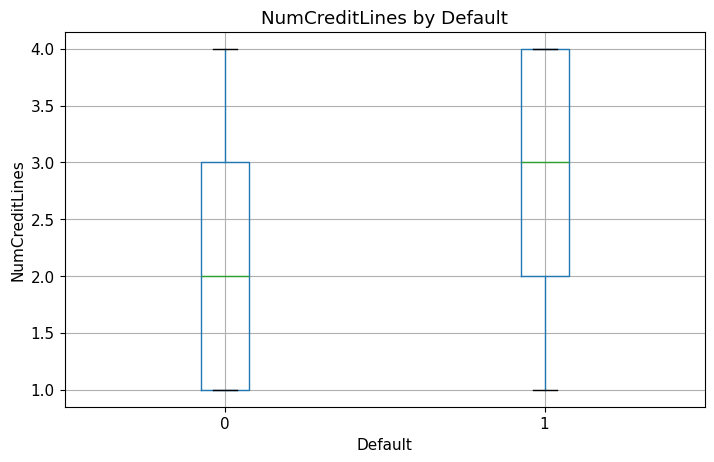

In [19]:
plot_boxplot(df, "NumCreditLines")

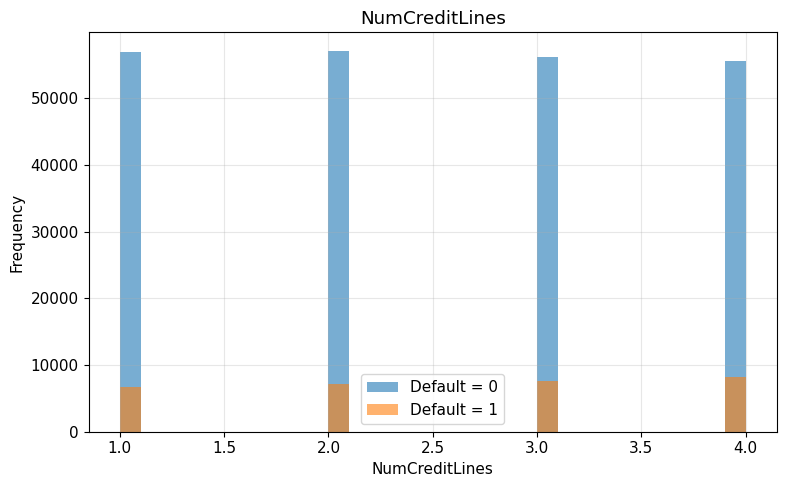

In [20]:
plot_histogram(df, "NumCreditLines")

In [21]:
credit_lines_risk = calculate_default_rate(
    df,
    category_col="NumCreditLines"
)

credit_lines_risk

,NumCreditLines,DefaultRate
0,1,10.52
1,2,11.06
2,3,11.92
3,4,12.94


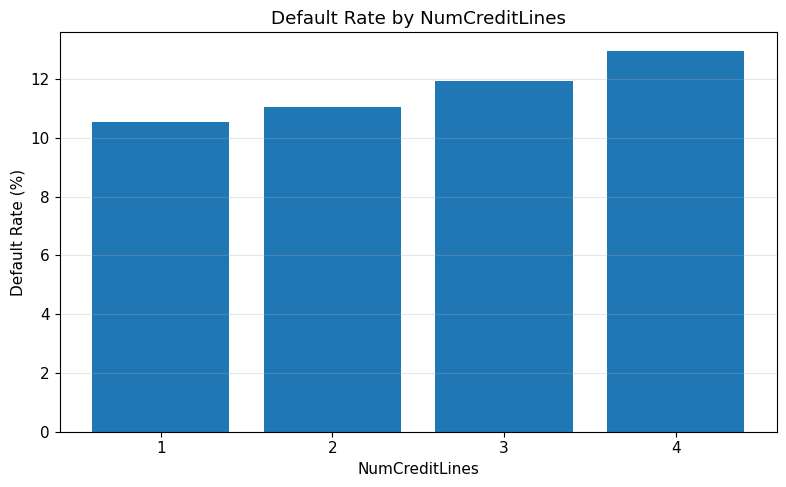

In [22]:
plot_default_rate(
    credit_lines_risk,
    category_col="NumCreditLines"
)

In [23]:
df_income = create_quantile_bands(
    df,
    "Income"
)

df_income.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,Income_Band
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0,"(69065.0, 95990.2]"
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0,"(42031.0, 69065.0]"
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1,"(69065.0, 95990.2]"
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0,"(14999.99, 42031.0]"
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0,"(14999.99, 42031.0]"


In [24]:
income_risk = calculate_default_rate(
    df_income,
    "Income_Band"
)

income_risk

,Income_Band,DefaultRate
0,"(14999.99, 42031.0]",18.54
1,"(42031.0, 69065.0]",11.38
2,"(69065.0, 95990.2]",9.86
3,"(95990.2, 122965.0]",9.31
4,"(122965.0, 149999.0]",8.97


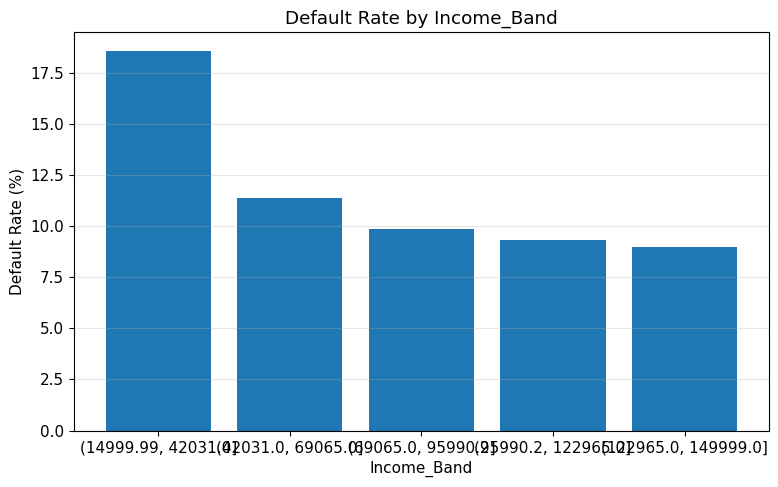

In [25]:
plot_default_rate(
    income_risk,
    "Income_Band"
)

**CONTINUE WITH MonthsEmployed**

In [26]:
# Testing fucntion with MonthsEmployed variable
calculate_descriptive_stats(df, "MonthsEmployed")

,count,mean,std,min,25%,50%,75%,max
Default,,,,,,,,
0,225694.0,60.76,34.56,0.0,31.0,61.0,91.0,119.0
1,29653.0,50.24,33.88,0.0,21.0,46.0,78.0,119.0


<Figure size 600x500 with 0 Axes>

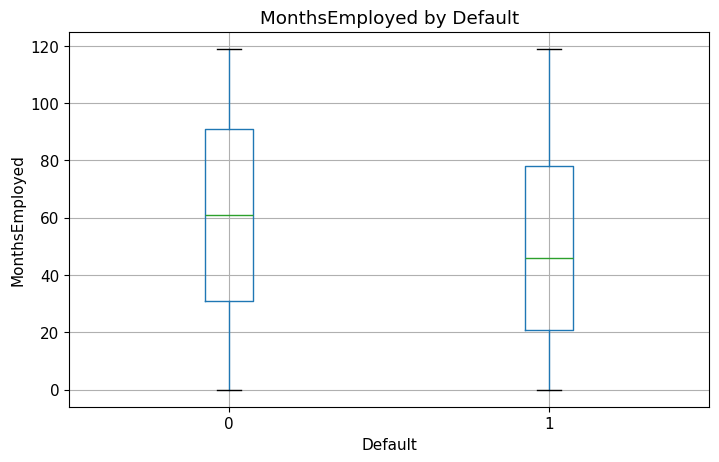

In [27]:
plot_boxplot(df, "MonthsEmployed")

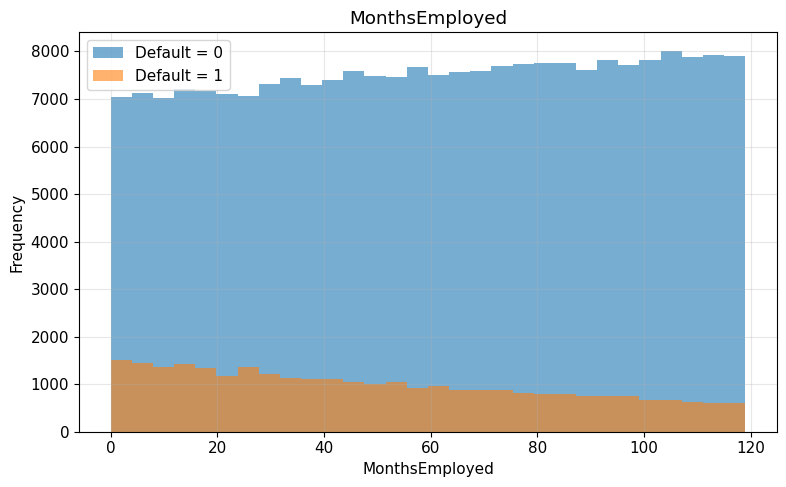

In [28]:
plot_histogram(df, "MonthsEmployed")

In [29]:
df_employment = create_quantile_bands(
    df,
    "MonthsEmployed"
)

In [30]:
employment_risk = calculate_default_rate(
    df_employment,
    "MonthsEmployed_Band"
)

employment_risk

,MonthsEmployed_Band,DefaultRate
0,"(-0.01, 24.0]",16.24
1,"(24.0, 48.0]",13.52
2,"(48.0, 72.0]",11.06
3,"(72.0, 96.0]",9.30
4,"(96.0, 119.0]",7.61


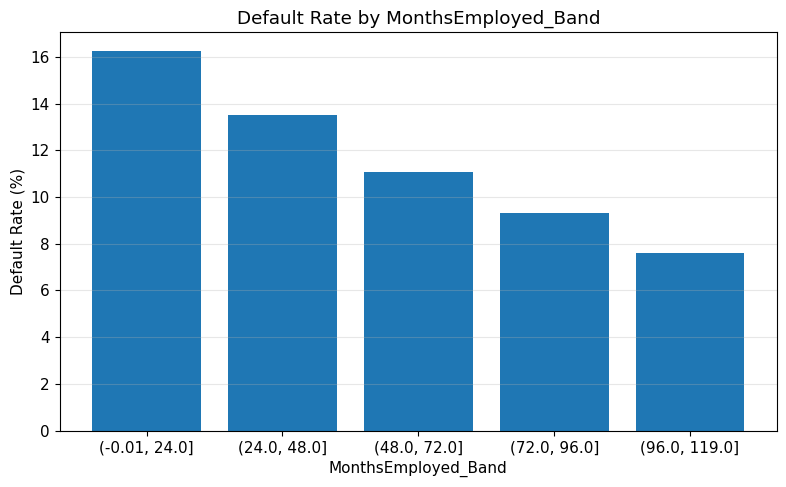

In [31]:
plot_default_rate(
    employment_risk,
    "MonthsEmployed_Band"
)

In [32]:
corr = df[["MonthsEmployed", "Default"]].corr()
corr

,MonthsEmployed,Default
MonthsEmployed,1.000000,-0.097374
Default,-0.097374,1.000000


**ANALYZING EmploymentType (categorical variable)**

In [33]:
employment_distribution = calculate_category_distribution(
    df,
    "EmploymentType",
)

employment_distribution

,EmploymentType,Count,Percentage
0,Part-time,64161,25.13
1,Unemployed,63824,25.00
2,Self-employed,63706,24.95
3,Full-time,63656,24.93


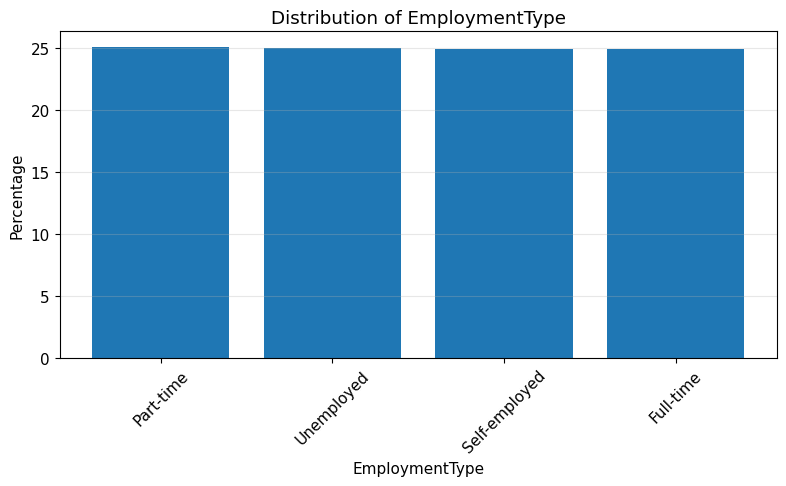

In [34]:
plot_category_distribution(
    employment_distribution,
    "EmploymentType",
    value_col="Percentage"
)

In [35]:
employment_risk = calculate_default_rate(
    df,
    "EmploymentType"
)

employment_risk

,EmploymentType,DefaultRate
0,Full-time,9.46
1,Part-time,11.97
2,Self-employed,11.46
3,Unemployed,13.55


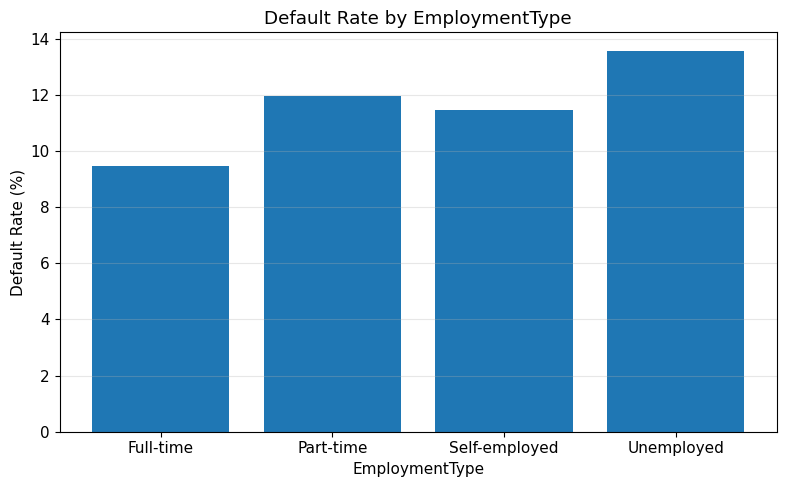

In [36]:
plot_default_rate(
    employment_risk,
    "EmploymentType"
)

**BIVARIATE ANALYSIS (Employment Stability): MonthsEmployed, EmploymentType**

In [37]:
df_employment = create_quantile_bands(
    df,
    "MonthsEmployed"
)

In [38]:
# Handly code, still there are not function

employment_matrix = (
    df_employment
    .pivot_table(
        values="Default",
        index="MonthsEmployed_Band",
        columns="EmploymentType",
        aggfunc="mean"
    )
    *100
).round(2)

employment_matrix

EmploymentType,Full-time,Part-time,Self-employed,Unemployed
MonthsEmployed_Band,,,,
"(-0.01, 24.0]",13.39,17.16,15.75,18.67
"(24.0, 48.0]",11.07,13.89,13.63,15.47
"(48.0, 72.0]",8.83,11.31,10.88,13.21
"(72.0, 96.0]",7.57,9.35,8.96,11.30
"(96.0, 119.0]",6.14,7.80,7.75,8.75


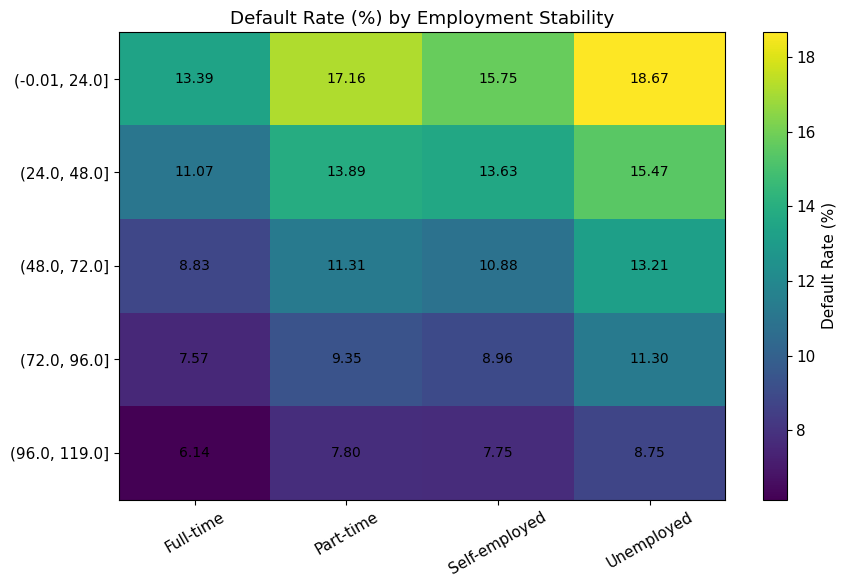

In [39]:
# Handly code, still there are not function

plt.figure(figsize=(9, 6))
plt.imshow(employment_matrix, aspect="auto")
plt.colorbar(label="Default Rate (%)")

# Axis labels
plt.xticks(
    np.arange(len(employment_matrix.columns)),
    employment_matrix.columns,
    rotation=30
)

plt.yticks(
    np.arange(len(employment_matrix.index)),
    employment_matrix.index
)

# Enter the value in each cell
for i in range(employment_matrix.shape[0]):
    for j in range(employment_matrix.shape[1]):

        plt.text(
            j,
            i,
            f"{employment_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=10
        )

plt.title("Default Rate (%) by Employment Stability")
plt.tight_layout()
plt.show()

**MULTIVARIATE ANALYSIS (Applicant profile): Age, Education, MaritalStatus, HasDependents**

In [40]:
# AGE
# Descriptive statistic
calculate_descriptive_stats(
    df,
    "Age"
)

,count,mean,std,min,25%,50%,75%,max
Default,,,,,,,,
0,225694.0,44.41,14.89,18.0,32.0,45.0,57.0,69.0
1,29653.0,36.56,13.90,18.0,25.0,34.0,47.0,69.0


<Figure size 600x500 with 0 Axes>

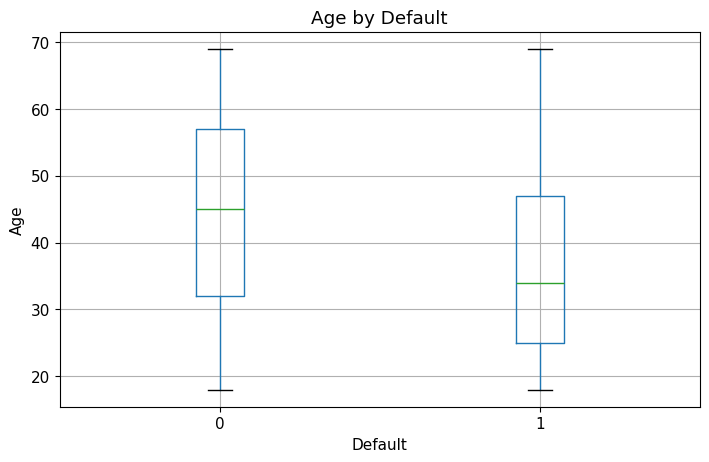

In [41]:
# Boxplot of Age
plot_boxplot(
    df,
    "Age"
)

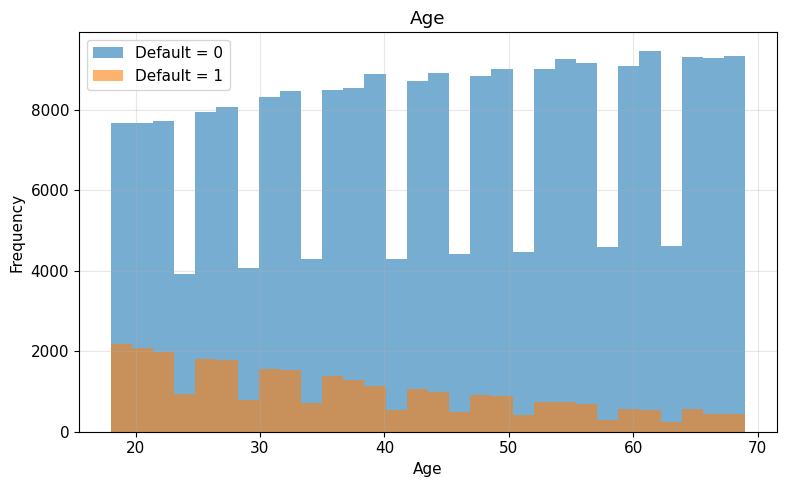

In [42]:
# Histogram of Age
plot_histogram(
    df,
    "Age"
)

In [43]:
# Create bands of Age
df_age = create_quantile_bands(
    df,
    "Age"
)

In [44]:
# Calculate default rate
age_risk = calculate_default_rate(
    df_age,
    "Age_Band"
)

age_risk

,Age_Band,DefaultRate
0,"(17.99, 28.0]",20.03
1,"(28.0, 38.0]",14.67
2,"(38.0, 49.0]",10.23
3,"(49.0, 59.0]",7.32
4,"(59.0, 69.0]",5.13


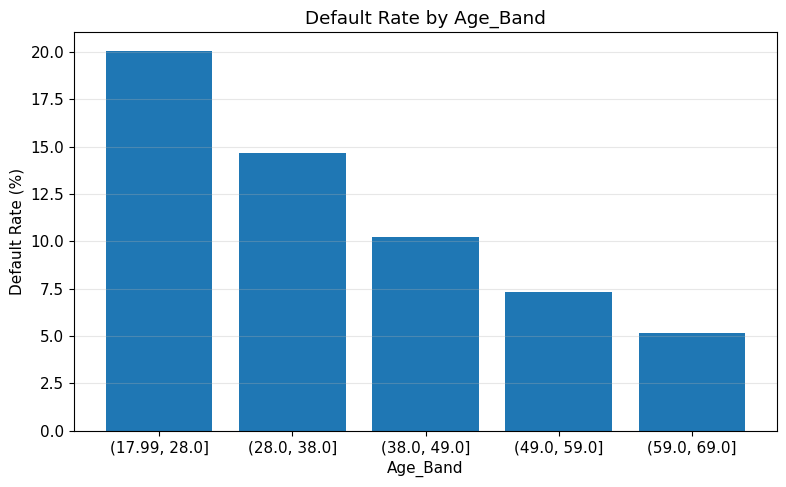

In [45]:
plot_default_rate(
    age_risk,
    "Age_Band"
)

In [46]:
corr = df[["Age", "Default"]].corr()
corr

,Age,Default
Age,1.000000,-0.167783
Default,-0.167783,1.000000


In [47]:
# EDUCATION
# Category distribution
education_distribution = calculate_category_distribution(
    df,
    "Education"
)

education_distribution

,Education,Count,Percentage
0,Bachelor's,64366,25.21
1,High School,63903,25.03
2,Master's,63541,24.88
3,PhD,63537,24.88


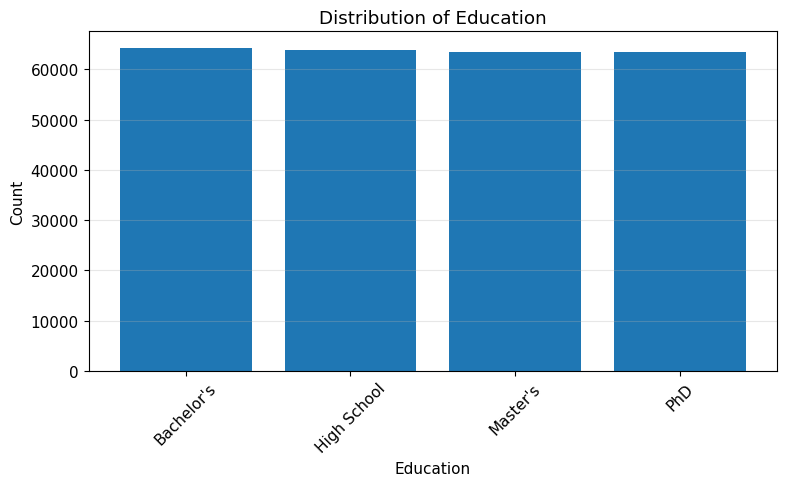

In [48]:
# Plotting Education distribution
plot_category_distribution(
    education_distribution,
    "Education"
)

In [49]:
# Default rate of Education
education_risk = calculate_default_rate(
    df,
    "Education"
)

education_risk

,Education,DefaultRate
0,Bachelor's,12.10
1,High School,12.88
2,Master's,10.87
3,PhD,10.59


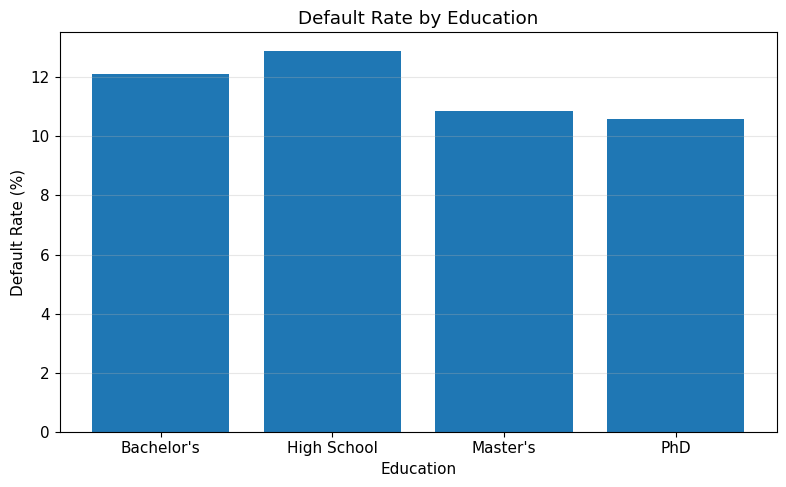

In [50]:
# Plotting default rate of Education
plot_default_rate(
    education_risk,
    "Education"
)

In [51]:
# Cross-tabulation table
education_table = pd.crosstab(
    df["Education"],
    df["Default"]
)

education_table

Default,0,1
Education,,
Bachelor's,56577,7789
High School,55673,8230
Master's,56633,6908
PhD,56811,6726


In [52]:
# Chi-square test
"""chi2, p_value, dof, expected = chi2_contingency(
    education_table
)

print(f"Chi²: {chi2:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")"""

# Testing Chi-square function
chi_square_test(df,"Education")

{'Chi2': np.float64(214.019),
 'p_value': np.float64(3.9404864175508716e-46),
 'Degrees_of_Freedom': 3,
 'Reject_H0': np.True_}

**How do you interpret the p-value?**

We will use a significance level of alpha = 0.05

if p < 0.05, we conclude that there is statistical evidence of an association between educational level and default.

if p >= 0.05, we conclude that there is insufficient evidence to assert that the two variables are associated.

Note: That doesn't imply causation. It merely indicates an **association**.

In [53]:
# Testing Cramer's V function
cramers_v(df,"Education")

np.float64(0.029)

In [54]:
# MARITAL STATUS
# Category distribution
marital_distribution = calculate_category_distribution(
    df,
    "MaritalStatus"
)

marital_distribution

,MaritalStatus,Count,Percentage
0,Married,85302,33.41
1,Divorced,85033,33.30
2,Single,85012,33.29


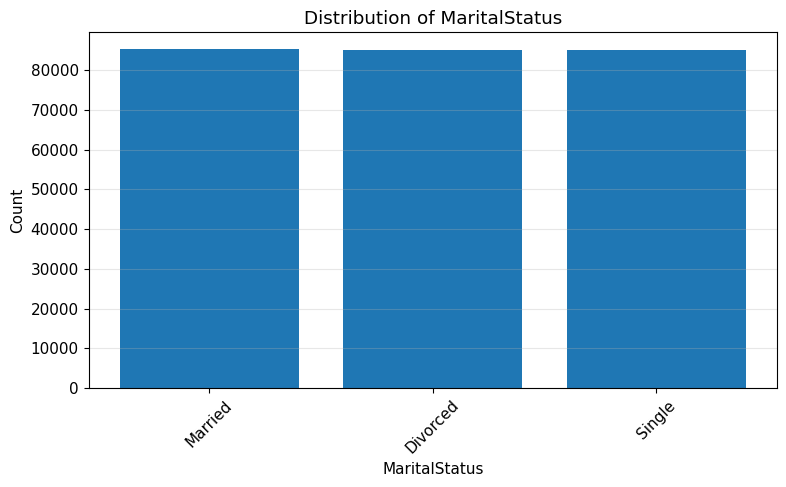

In [55]:
# Plotting MaritalStatus distribution
plot_category_distribution(
    marital_distribution,
    "MaritalStatus"
)

In [56]:
# Default rate of MaritalStatus
marital_risk = calculate_default_rate(
    df,
    "MaritalStatus"
)

marital_risk

,MaritalStatus,DefaultRate
0,Divorced,12.53
1,Married,10.40
2,Single,11.91


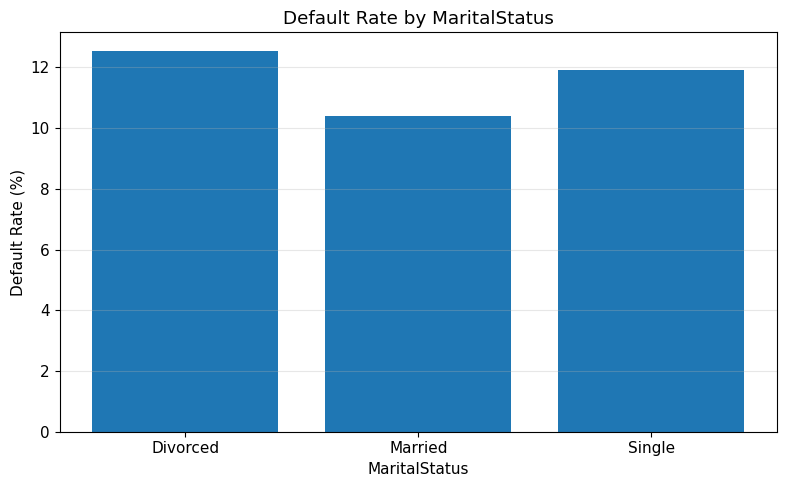

In [57]:
# Plotting default rate of MaritalStatus
plot_default_rate(
    marital_risk,
    "MaritalStatus"
)

In [58]:
# Chi-square test with MaritalStatus
chi_square_test(
    df,
    "MaritalStatus"
)

{'Chi2': np.float64(200.3611),
 'p_value': np.float64(3.105504830442356e-44),
 'Degrees_of_Freedom': 2,
 'Reject_H0': np.True_}

In [59]:
# Cramer's V with MaritalStatus
cramers_v(
    df,
    "MaritalStatus"
)

np.float64(0.028)

In [60]:
# HAS DEPENDENTS
# Category distribution
dependents_distribution = calculate_category_distribution(
    df,
    "HasDependents"
)

dependents_distribution

,HasDependents,Count,Percentage
0,Yes,127742,50.03
1,No,127605,49.97


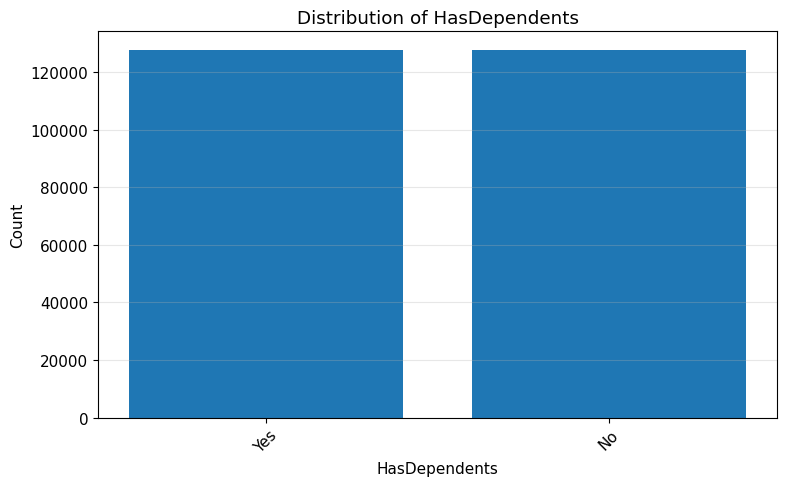

In [61]:
# Plotting HasDependents distribution
plot_category_distribution(
    dependents_distribution,
    "HasDependents"
)

In [62]:
# Default rate of HasDependents
dependents_risk = calculate_default_rate(
    df,
    "HasDependents"
)

dependents_risk

,HasDependents,DefaultRate
0,No,12.72
1,Yes,10.50


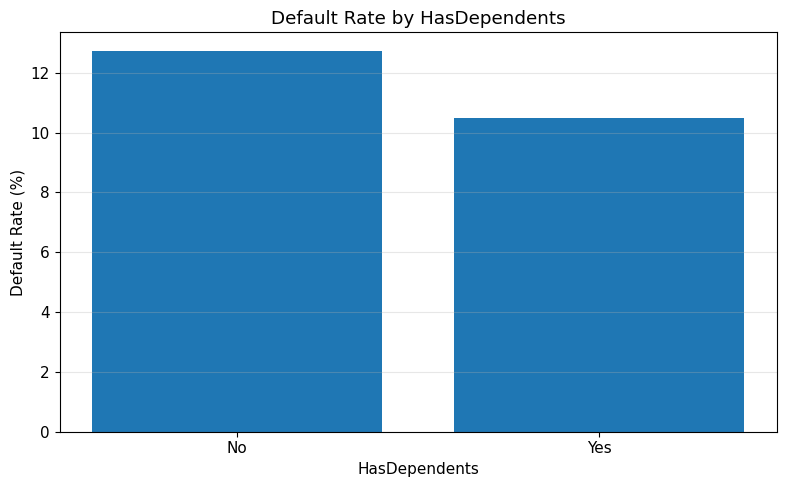

In [63]:
# Plotting default rate of HasDependents
plot_default_rate(
    dependents_risk,
    "HasDependents"
)

In [64]:
# Chi-square test with HasDependents
chi_square_test(df,"HasDependents")

{'Chi2': np.float64(306.8506),
 'p_value': np.float64(1.0600086119645882e-68),
 'Degrees_of_Freedom': 1,
 'Reject_H0': np.True_}

In [65]:
# Cramer's V with HasDependents
cramers_v(df,"HasDependents")

np.float64(0.0347)

**BLOCK 5: LOAN CHARACTERISTICS**

In [66]:
# LOAN PURPOSE
# Category distribution
loanpurpose_distribution = calculate_category_distribution(
    df,
    "LoanPurpose"
)

loanpurpose_distribution

,LoanPurpose,Count,Percentage
0,Business,51298,20.09
1,Home,51286,20.08
2,Education,51005,19.97
3,Other,50914,19.94
4,Auto,50844,19.91


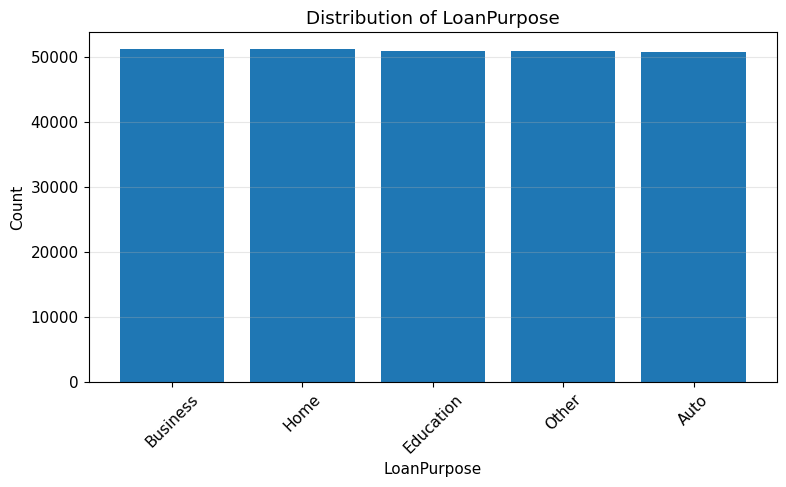

In [67]:
# Plotting LoanPurpose distribution
plot_category_distribution(
    loanpurpose_distribution,
    "LoanPurpose"
)

In [68]:
# Default rate of LoanPurpose
loanpurpose_risk = calculate_default_rate(
    df,
    "LoanPurpose"
)

loanpurpose_risk

,LoanPurpose,DefaultRate
0,Auto,11.88
1,Business,12.33
2,Education,11.84
3,Home,10.23
4,Other,11.79


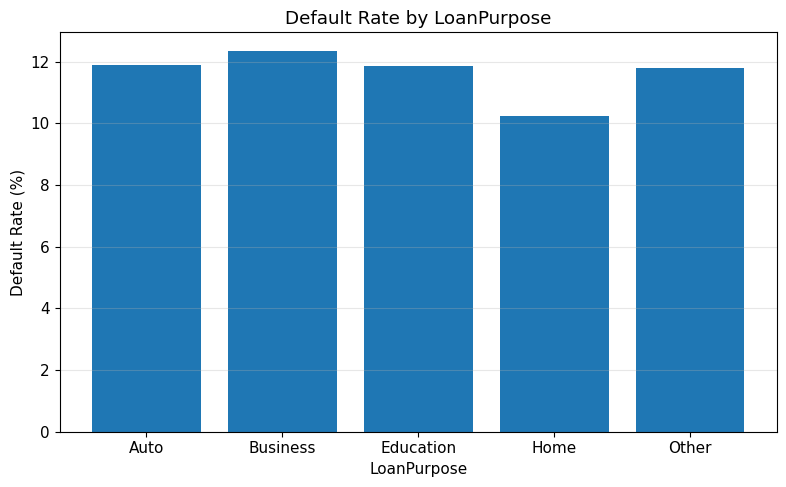

In [69]:
# Plotting default rate of LoanPurpose
plot_default_rate(
    loanpurpose_risk,
    "LoanPurpose"
)

In [70]:
# Chi-square test with LoanPurpose
chi_square_test(df,"LoanPurpose")

{'Chi2': np.float64(127.9342),
 'p_value': np.float64(1.0767865809403042e-26),
 'Degrees_of_Freedom': 4,
 'Reject_H0': np.True_}

In [71]:
# Cramer's V with LoanPurpose
cramers_v(df,"LoanPurpose")

np.float64(0.0224)

In [72]:
# Descriptive statistic of InterestRate
calculate_descriptive_stats(
    df,
    "InterestRate"
)

,count,mean,std,min,25%,50%,75%,max
Default,,,,,,,,
0,225694.0,13.18,6.61,2.0,7.45,12.99,18.85,25.0
1,29653.0,15.90,6.32,2.0,11.06,16.93,21.36,25.0


<Figure size 600x500 with 0 Axes>

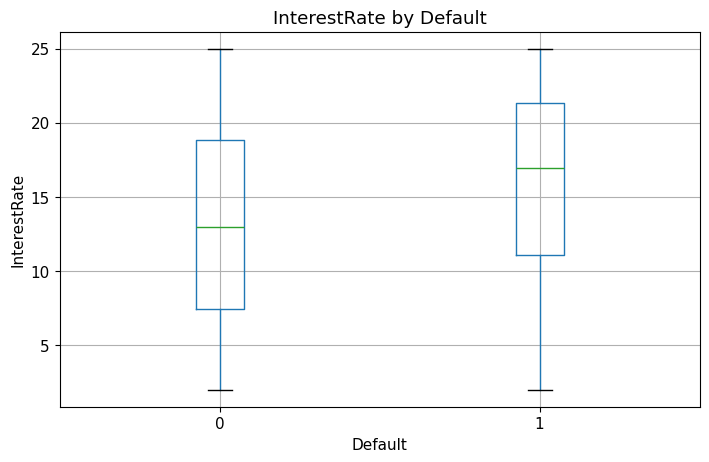

In [73]:
# Plotting InterestRate
plot_boxplot(
    df,
    "InterestRate"
)

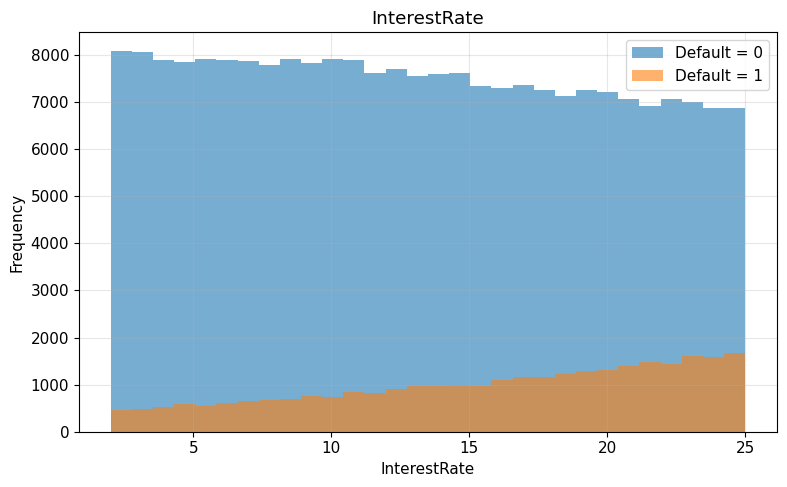

In [74]:
# Histogram of InterestRate
plot_histogram(
    df,
    "InterestRate",
    target_col="Default"
)

In [75]:
# Creating bands of InterestRate
df = create_quantile_bands(
    df,
    "InterestRate",
    q=5
)

In [76]:
# Default rate of InterestRate
interest_risk = calculate_default_rate(
    df,
    "InterestRate_Band"
)

interest_risk

,InterestRate_Band,DefaultRate
0,"(1.99, 6.62]",6.31
1,"(6.62, 11.18]",8.43
2,"(11.18, 15.76]",11.07
3,"(15.76, 20.4]",14.23
4,"(20.4, 25.0]",18.04


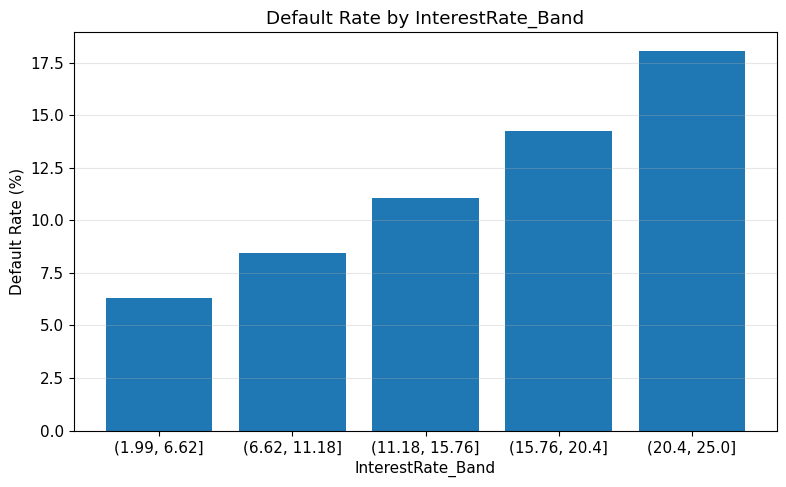

In [77]:
# Plotting default of InterestRate
plot_default_rate(
    interest_risk,
    "InterestRate_Band"
)

In [78]:
# Correlation between InterestRate and Default
df[["InterestRate","Default"]].corr()

,InterestRate,Default
InterestRate,1.000000,0.131273
Default,0.131273,1.000000


In [79]:
# Descriptive statistic of LoanTerm
calculate_descriptive_stats(
    df,
    "LoanTerm"
)

,count,mean,std,min,25%,50%,75%,max
Default,,,,,,,,
0,225694.0,36.02,16.97,12.0,24.0,36.0,48.0,60.0
1,29653.0,36.05,16.99,12.0,24.0,36.0,48.0,60.0


<Figure size 600x500 with 0 Axes>

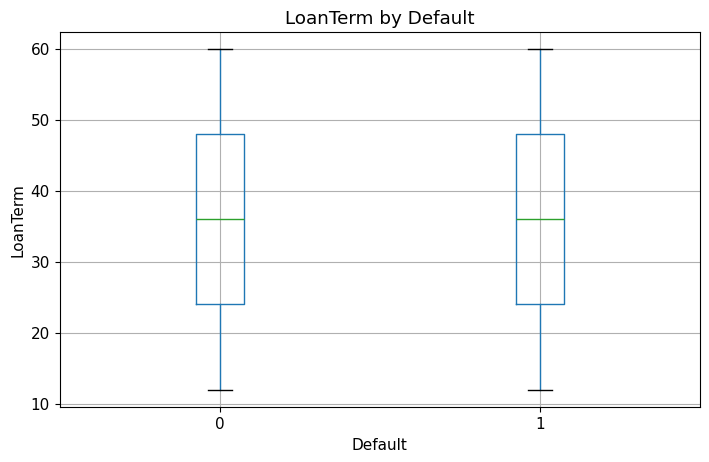

In [80]:
# Plotting LoanTerm
plot_boxplot(
    df,
    "LoanTerm"
)

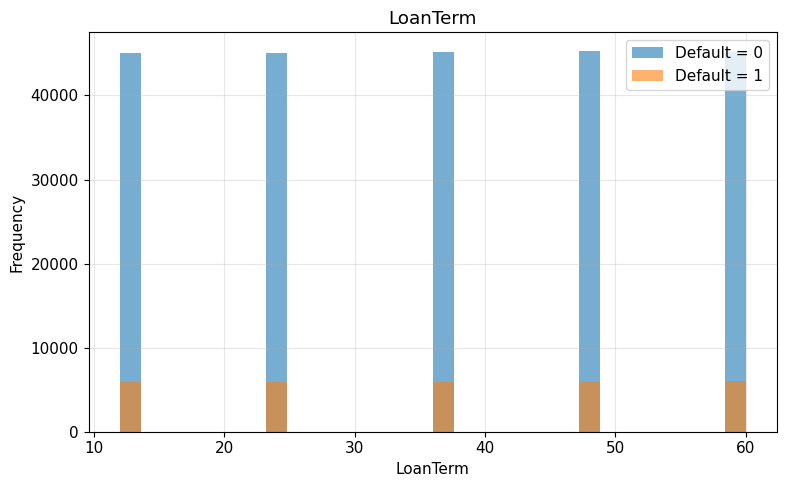

In [81]:
# Histogram of LoanTerm
plot_histogram(
    df,
    "LoanTerm",
    target_col="Default"
)

In [82]:
# Default rate of LoanTerm
loanterm_risk = calculate_default_rate(
    df,
    "LoanTerm"
)

loanterm_risk

,LoanTerm,DefaultRate
0,12,11.62
1,24,11.61
2,36,11.57
3,48,11.57
4,60,11.70


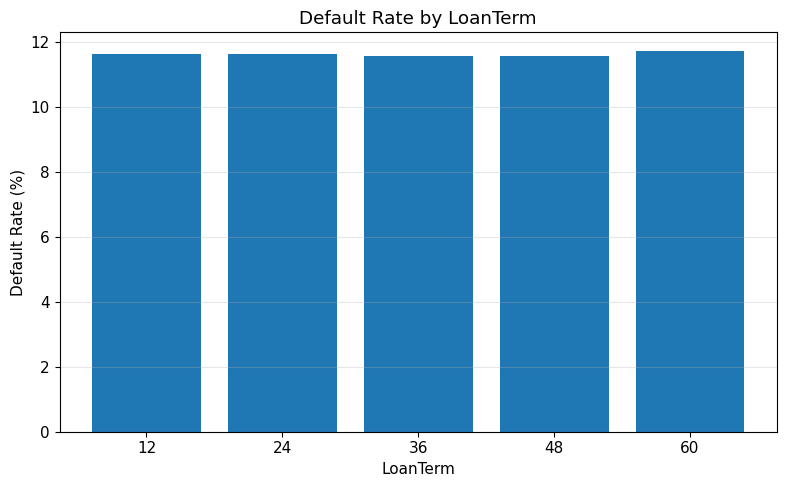

In [83]:
# Plotting default of LoanTerm
plot_default_rate(
    loanterm_risk,
    "LoanTerm"
)

In [84]:
# Correlation between LoanTerm and Default
df[["LoanTerm","Default"]].corr()

,LoanTerm,Default
LoanTerm,1.000000,0.000545
Default,0.000545,1.000000


**BIVARIATE ANALYSIS: LOAN CHARACTERISTICS**

**LoanAmount × InterestRate**

In [85]:
# Analyzing LoanAmount
# Descriptive statistic
calculate_descriptive_stats(
    df,
    "LoanAmount"
)

,count,mean,std,min,25%,50%,75%,max
Default,,,,,,,,
0,225694.0,125353.66,70708.10,5001.0,63889.25,124236.0,186177.75,249999.0
1,29653.0,144515.31,69547.82,5000.0,88085.00,152672.0,205468.00,249993.0


<Figure size 600x500 with 0 Axes>

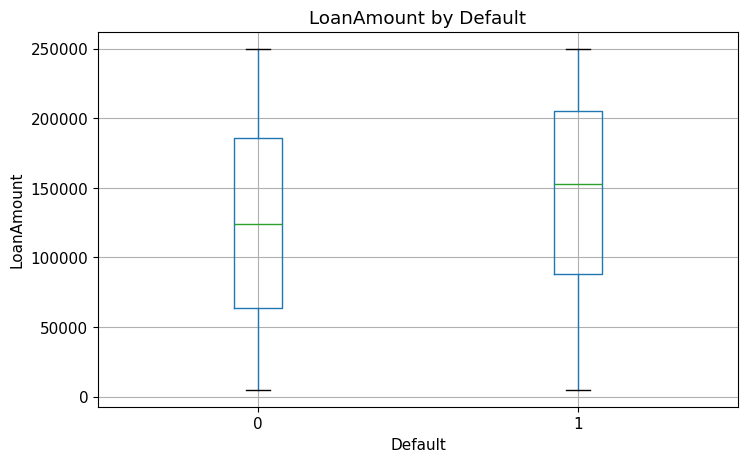

In [86]:
# Boxplot of LoanAmount by default
plot_boxplot(
    df,
    "LoanAmount"
)

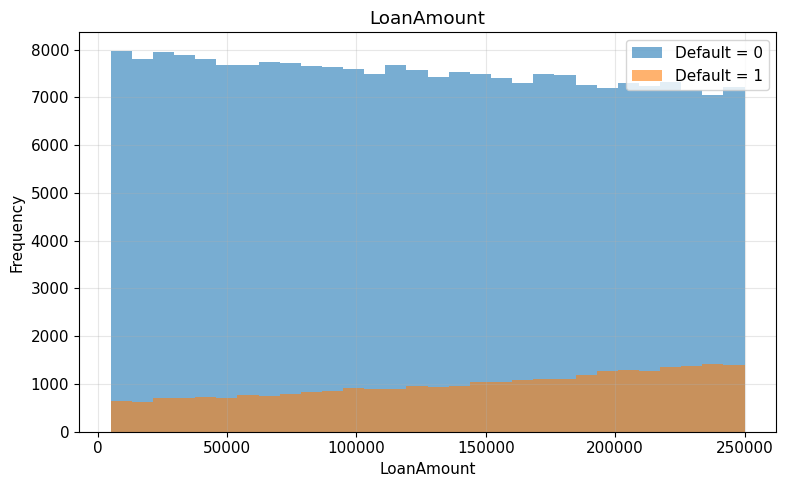

In [87]:
# Histogram of LoanAmount
plot_histogram(
    df,
    "LoanAmount",
    target_col="Default"
)

In [88]:
# Creating bands of LoanAmount
df = create_quantile_bands(
    df,
    "LoanAmount",
    q=5
)

In [89]:
# Default rate of LoanAmount
loan_risk = calculate_default_rate(
    df,
    "LoanAmount_Band"
)

loan_risk

,LoanAmount_Band,DefaultRate
0,"(4999.99, 53873.2]",8.05
1,"(53873.2, 102995.8]",9.67
2,"(102995.8, 152186.8]",11.20
3,"(152186.8, 201313.0]",13.34
4,"(201313.0, 249999.0]",15.82


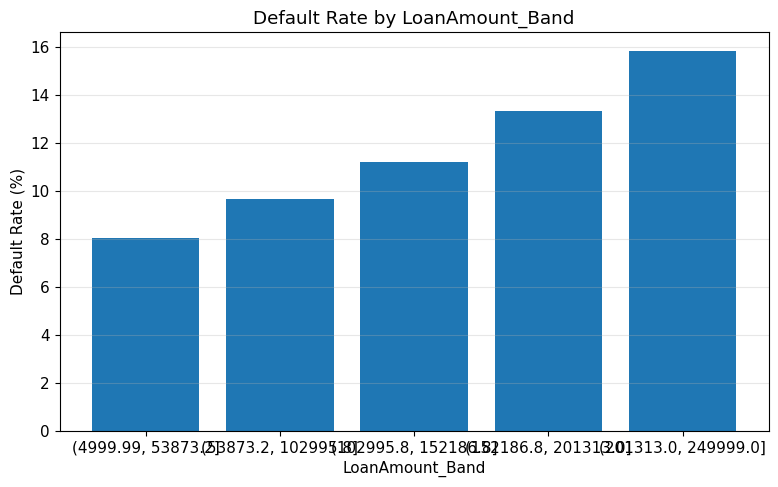

In [90]:
# Plotting default of LoanAmount
plot_default_rate(
    loan_risk,
    "LoanAmount_Band"
)

In [91]:
# Calculating the correlation with the target
df[["LoanAmount", "Default"]].corr()

,LoanAmount,Default
LoanAmount,1.000000,0.086659
Default,0.086659,1.000000


In [92]:
# Creating cross table
loan_interest_matrix = (
    df
    .groupby(
        [
            "LoanAmount_Band",
            "InterestRate_Band"
        ]
    )["Default"]
    .mean()
    .mul(100)
    .round(2)
    .unstack()
)

loan_interest_matrix

InterestRate_Band,"(1.99, 6.62]","(6.62, 11.18]","(11.18, 15.76]","(15.76, 20.4]","(20.4, 25.0]"
LoanAmount_Band,,,,,
"(4999.99, 53873.2]",4.25,5.61,7.02,9.97,13.43
"(53873.2, 102995.8]",4.93,6.67,9.07,12.51,15.05
"(102995.8, 152186.8]",5.92,8.11,10.72,13.70,17.48
"(152186.8, 201313.0]",7.42,9.56,13.11,16.42,20.31
"(201313.0, 249999.0]",9.02,12.19,15.39,18.58,24.03


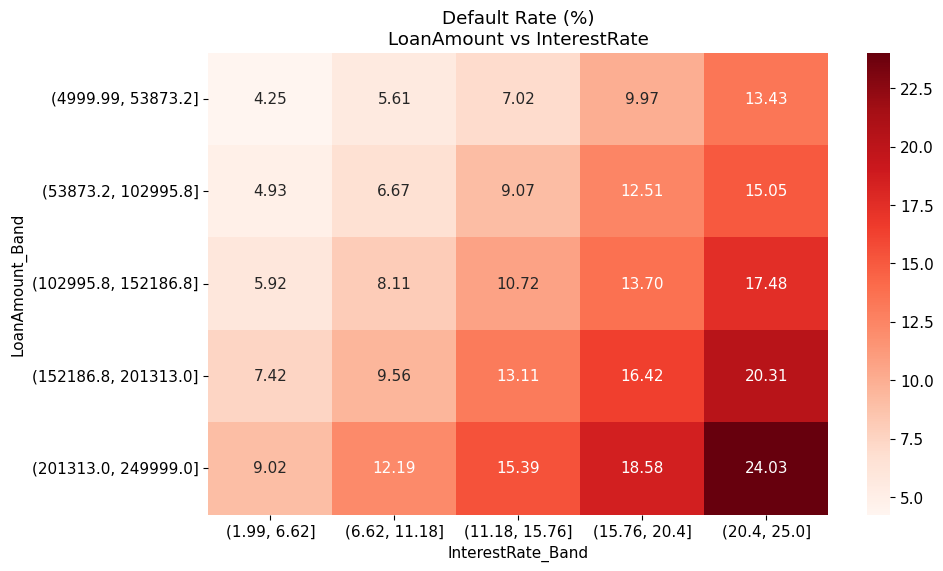

In [93]:
# Heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    loan_interest_matrix,
    annot=True,
    fmt=".2f",
    cmap="Reds"
)

plt.title("Default Rate (%)\nLoanAmount vs InterestRate")

plt.show()

**LoanAmount × LoanTerm**

In [94]:
# Creating cross table
loanamount_term_matrix = (
    df
    .groupby(
        [
            "LoanAmount_Band",
            "LoanTerm"
        ]
    )["Default"]
    .mean()
    .mul(100)
    .round(2)
    .unstack()
)

loanamount_term_matrix

LoanTerm,12,24,36,48,60
LoanAmount_Band,,,,,
"(4999.99, 53873.2]",7.90,8.21,7.88,8.20,8.06
"(53873.2, 102995.8]",9.53,9.68,9.56,9.68,9.87
"(102995.8, 152186.8]",11.00,10.94,11.04,11.24,11.76
"(152186.8, 201313.0]",14.05,13.05,13.26,13.07,13.26
"(201313.0, 249999.0]",15.66,16.15,16.08,15.66,15.52


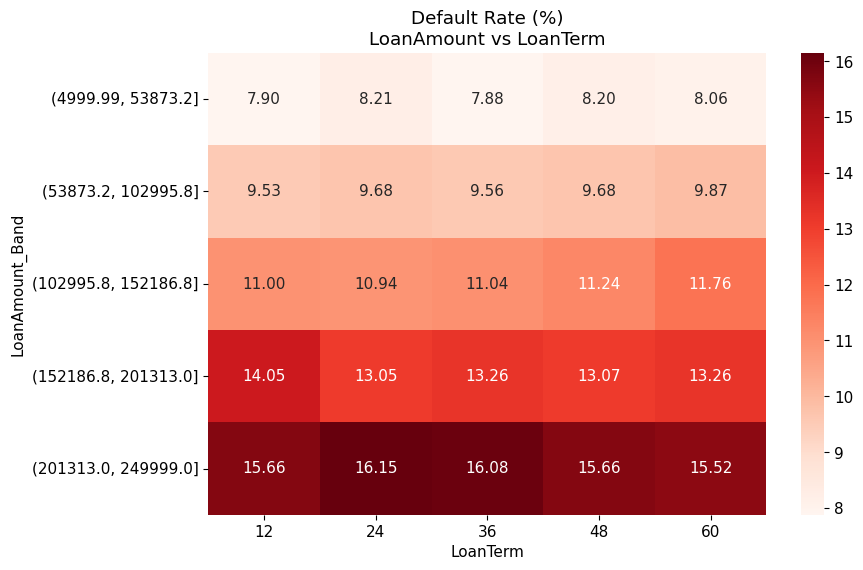

In [95]:
# Heatmap
plt.figure(figsize=(9,6))

sns.heatmap(
    loanamount_term_matrix,
    annot=True,
    fmt=".2f",
    cmap="Reds"
)

plt.title("Default Rate (%)\nLoanAmount vs LoanTerm")

plt.show()

**InterestRate × LoanPurpose**

In [96]:
# Cross table
interest_purpose_matrix = (
    df
    .groupby(
        [
            "InterestRate_Band",
            "LoanPurpose"
        ]
    )["Default"]
    .mean()
    .mul(100)
    .round(2)
    .unstack()
)

interest_purpose_matrix

LoanPurpose,Auto,Business,Education,Home,Other
InterestRate_Band,,,,,
"(1.99, 6.62]",6.34,6.82,6.51,5.53,6.36
"(6.62, 11.18]",8.86,8.99,8.53,7.01,8.78
"(11.18, 15.76]",11.37,11.84,11.00,9.76,11.36
"(15.76, 20.4]",14.52,15.06,14.70,12.46,14.39
"(20.4, 25.0]",18.43,19.00,18.38,16.32,18.12


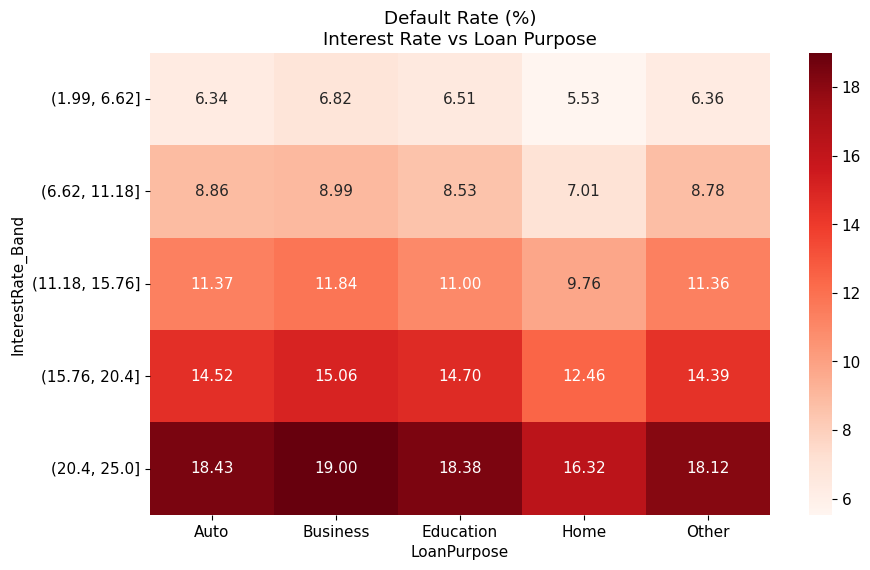

In [97]:
# Heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    interest_purpose_matrix,
    annot=True,
    fmt=".2f",
    cmap="Reds"
)

plt.title(
    "Default Rate (%)\nInterest Rate vs Loan Purpose"
)

plt.show()

In [98]:
df.columns

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default',
       'InterestRate_Band', 'LoanAmount_Band'],
      dtype='object')